# World Bank API: From Indicator Search to Data Story



The World Bank Indicators API provides public access to economic, demographic, environmental, and social data. It does not require an API key.

### Learning goals

By the end of this activity, you should be able to:

- use an API to find indicator names and codes;
- inspect a JSON response;
- convert API records into a pandas DataFrame;
- clean dates, numerical values, and missing data;
- use filtering, `groupby`, and a basic `for` loop;
- create a Seaborn visualization;
- explain what an API-based analysis shows and what it does not establish.

### Schedule

| Time | Activity |
|---:|---|
| 0–10 min | Search for indicator codes |
| 10–20 min | Complete a guided example |
| 20–27 min | Form groups and choose a question |
| 27–42 min | Request, clean, and inspect data |
| 42–52 min | Filter, summarize, and use a loop |
| 52–62 min | Create and revise a visualization |
| 62–68 min | Write findings and limitations |
| 68–70 min | Rapid share-out |

## Setup

In [1]:
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Part I — Find an indicator code

World Bank data series have codes such as `SP.POP.TOTL` for total population. You do not need to memorize these codes. We can request the World Development Indicators catalog and search it with pandas.

The endpoint below uses source `2`, the World Development Indicators collection.

In [4]:
catalog_url = "https://api.worldbank.org/v2/source/2/indicator"

catalog_params = {
    "format": "json",
    "per_page": 5000,
}

catalog_response = requests.get(
    catalog_url,
    params=catalog_params,
    timeout=30,
)

catalog_json = catalog_response.json()

In [5]:
catalog_response

<Response [200]>

In [7]:
type(catalog_json)

list

The response contains two elements:

- `catalog_json[0]` contains information about the response, including the number of pages and records.
- `catalog_json[1]` contains the indicator records.

In [8]:
catalog_json[0]

{'page': 1, 'pages': 1, 'per_page': '5000', 'total': 1498}

In [9]:
print("Response type:", type(catalog_json))
print("Number of response elements:", len(catalog_json))
print("First indicator record:")
catalog_json[1][0]

Response type: <class 'list'>
Number of response elements: 2
First indicator record:


{'id': 'AG.CON.FERT.PT.ZS',
 'name': 'Fertilizer consumption (% of fertilizer production)',
 'unit': '',
 'source': {'id': '2', 'value': 'World Development Indicators'},
 'sourceNote': "Fertilizer consumption measures the quantity of plant nutrients and is calculated as production plus imports minus exports. Fertilizer products cover nitrogenous, potash, and phosphate fertilizers (including ground rock phosphate). Traditional nutrients--animal and plant manures--are not included. Because some chemical compounds used for fertilizers have other industrial applications, the consumption data may overstate the quantity available for crops. Fertilizer consumption as a share of production shows the agriculture sector's vulnerability to import and energy price fluctuation. Most fertilizers that are commonly used in agriculture contain the three basic plant nutrients-nitrogen, phosphorus, and potassium. Some fertilizers also contain certain micronutrients such as zinc and other metals that are 

## Convert the catalog to a DataFrame

In [10]:
indicator_catalog = pd.json_normalize(catalog_json[1])

In [11]:
indicator_catalog = indicator_catalog[
    ["id", "name", "source.value", "sourceNote"]
].rename(
    columns={
        "id": "indicator_code",
        "name": "indicator_name",
        "source.value": "source",
        "sourceNote": "description",
    }
)

In [12]:
indicator_catalog.head()

,indicator_code,indicator_name,source,description
0,AG.CON.FERT.PT.ZS,Fertilizer consumption (% of fertilizer produc...,World Development Indicators,Fertilizer consumption measures the quantity o...
1,AG.CON.FERT.ZS,Fertilizer consumption (kilograms per hectare ...,World Development Indicators,Fertilizer consumption measures the quantity o...
2,AG.LND.AGRI.K2,Agricultural land (sq. km),World Development Indicators,Agricultural land refers to the land area that...
3,AG.LND.AGRI.ZS,Agricultural land (% of land area),World Development Indicators,Agricultural land refers to the share of land ...
4,AG.LND.ARBL.HA,Arable land (hectares),World Development Indicators,Arable land (in hectares) includes land define...


In [13]:
print("Indicators in catalog:", len(indicator_catalog))
indicator_catalog.info()

Indicators in catalog: 1498
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   indicator_code  1498 non-null   object
 1   indicator_name  1498 non-null   object
 2   source          1498 non-null   object
 3   description     1498 non-null   object
dtypes: object(4)
memory usage: 46.9+ KB


## Search the catalog

`.str.contains()` searches the indicator names for a word or phrase. `case=False` ignores capitalization and `na=False` prevents missing text from causing an error.

In [14]:
search_term = "unemployment"

matches = indicator_catalog.loc[
    indicator_catalog["indicator_name"].str.contains(
        search_term,
        case=False,
        na=False,
    )
]

matches[["indicator_code", "indicator_name"]].head(20)

,indicator_code,indicator_name
783,per_lm_alllm.adq_pop_tot,Adequacy of unemployment benefits and ALMP (% ...
784,per_lm_alllm.ben_q1_tot,Benefit incidence of unemployment benefits and...
785,per_lm_alllm.cov_pop_tot,Coverage of unemployment benefits and ALMP (% ...
786,per_lm_alllm.cov_q1_tot,Coverage of unemployment benefits and ALMP in ...
787,per_lm_alllm.cov_q2_tot,Coverage of unemployment benefits and ALMP in ...
788,per_lm_alllm.cov_q3_tot,Coverage of unemployment benefits and ALMP in ...
789,per_lm_alllm.cov_q4_tot,Coverage of unemployment benefits and ALMP in ...
790,per_lm_alllm.cov_q5_tot,Coverage of unemployment benefits and ALMP in ...
1259,SL.UEM.1524.FE.NE.ZS,"Unemployment, youth female (% of female labor ..."
1260,SL.UEM.1524.FE.ZS,"Unemployment, youth female (% of female labor ..."


Sometimes a useful term appears in the description rather than the indicator name. The `|` symbol means “or” when combining pandas conditions.

In [15]:
search_term = "renewable"

matches = indicator_catalog[
    indicator_catalog["indicator_name"].str.contains(
        search_term, case=False, na=False
    )
    |
    indicator_catalog["description"].str.contains(
        search_term, case=False, na=False
    )
]

matches[
    ["indicator_code", "indicator_name", "description"]
].head(10)

,indicator_code,indicator_name,description
218,EG.ELC.RNEW.ZS,Renewable electricity output (% of total elect...,Renewable electricity is the share of electric...
219,EG.ELC.RNWX.KH,"Electricity production from renewable sources,...",Electricity production from renewable sources ...
220,EG.ELC.RNWX.ZS,"Electricity production from renewable sources,...",The share of electricity production from renew...
221,EG.FEC.RNEW.ZS,Renewable energy consumption (% of total final...,Renewable energy consumption is the share of r...
228,EG.USE.CRNW.ZS,Combustible renewables and waste (% of total e...,Combustible renewables and waste comprise soli...
298,ER.H2O.FWAG.ZS,"Annual freshwater withdrawals, agriculture (% ...",Annual freshwater withdrawals refer to total w...
299,ER.H2O.FWDM.ZS,"Annual freshwater withdrawals, domestic (% of ...",Annual freshwater withdrawals refer to total w...
300,ER.H2O.FWIN.ZS,"Annual freshwater withdrawals, industry (% of ...",Annual freshwater withdrawals refer to total w...
301,ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal a...,The level of water stress: freshwater withdraw...
302,ER.H2O.FWTL.K3,"Annual freshwater withdrawals, total (billion ...",Annual freshwater withdrawals refer to total w...


### Quick practice — Find three indicators (4 minutes)

Find:

1. one indicator related to education;
2. one related to technology or internet access;
3. one related to poverty or inequality.

For each, record its code and read its description. Choose indicators based on what they measure, not only on whether the title contains your search word.

In [ ]:
# Change this term and rerun the search.
search_term = "education"

practice_matches = indicator_catalog[
    indicator_catalog["indicator_name"].str.contains(
        search_term, case=False, na=False
    )
]

practice_matches[
    ["indicator_code", "indicator_name", "description"]
].head(20)

**Indicator 1:**  
**Indicator 2:**  
**Indicator 3:**  

**Which indicator would you most like to investigate, and why?**

# Part II — Guided example: life expectancy

We will compare life expectancy in Brazil, India, South Africa, and the United States from 2000 through 2023.

- Indicator: life expectancy at birth, total
- Code: `SP.DYN.LE00.IN`
- Countries: `BRA`, `IND`, `ZAF`, and `USA`

Country codes are separated by semicolons in a multi-country request.

In [17]:
indicator_code = "SP.DYN.LE00.IN"
countries = "BRA;IND;ZAF;USA"

data_url = (
    "https://api.worldbank.org/v2/"
    f"country/{countries}/"
    f"indicator/{indicator_code}"
)

data_params = {
    "format": "json",
    "date": "2000:2023",
    "per_page": 1000,
}

response = requests.get(
    data_url,
    params=data_params,
    timeout=30,
)


life_json = response.json()

## Inspect before converting

Do not immediately assume the response contains the data you expected. Check the metadata and one observation first.

In [18]:
print("Request information:")
display(life_json[0])

print("First observation:")
display(life_json[1][0])

Request information:


{'page': 1,
 'pages': 1,
 'per_page': 1000,
 'total': 96,
 'sourceid': '2',
 'lastupdated': '2026-07-13'}

First observation:


{'indicator': {'id': 'SP.DYN.LE00.IN',
  'value': 'Life expectancy at birth, total (years)'},
 'country': {'id': 'BR', 'value': 'Brazil'},
 'countryiso3code': 'BRA',
 'date': '2023',
 'value': 75.848,
 'unit': '',
 'obs_status': '',
 'decimal': 0}

### Check your understanding

1. What does one record in `life_json[1]` represent?
2. Where are the country, year, indicator, and value stored?
3. What type is the year before cleaning?
4. What might a value of `None` mean?

**Response:**

## Construct and clean the DataFrame

In [19]:
life_expectancy = pd.json_normalize(life_json[1])

life_expectancy = life_expectancy[
    ["country.value", "countryiso3code", "date", "value"]
].rename(
    columns={
        "country.value": "country",
        "countryiso3code": "country_code",
        "date": "year",
        "value": "life_expectancy",
    }
)

life_expectancy.head()

,country,country_code,year,life_expectancy
0,Brazil,BRA,2023,75.848
1,Brazil,BRA,2022,74.872
2,Brazil,BRA,2021,73.038
3,Brazil,BRA,2020,74.506
4,Brazil,BRA,2019,75.809


In [20]:
life_expectancy["year"] = pd.to_numeric(
    life_expectancy["year"],
    errors="coerce",
)

life_expectancy["life_expectancy"] = pd.to_numeric(
    life_expectancy["life_expectancy"],
    errors="coerce",
)

life_expectancy = life_expectancy.sort_values(
    ["country", "year"]
)

life_expectancy.head()

,country,country_code,year,life_expectancy
23,Brazil,BRA,2000,69.584
22,Brazil,BRA,2001,69.980
21,Brazil,BRA,2002,70.396
20,Brazil,BRA,2003,70.884
19,Brazil,BRA,2004,71.361


## Inspect and summarize

In [21]:
print("Shape:", life_expectancy.shape)
display(life_expectancy.isna().sum())
life_expectancy.info()

Shape: (96, 4)


country            0
country_code       0
year               0
life_expectancy    0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 23 to 48
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          96 non-null     object 
 1   country_code     96 non-null     object 
 2   year             96 non-null     int64  
 3   life_expectancy  96 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.8+ KB


In [22]:
life_expectancy.groupby(
    "country",
    observed=True,
)["life_expectancy"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Brazil,24.0,73.4,1.9,69.6,72.2,73.9,74.9,75.8
India,24.0,67.5,2.8,62.7,65.3,67.5,69.8,72.0
South Africa,24.0,60.3,4.5,53.9,55.9,61.2,64.8,66.1
United States,24.0,77.9,0.8,76.3,77.3,78.2,78.6,78.8


## Use a basic loop

This loop repeats the same filter and average for each country. The indented lines run once for every name in `country_names`.

In [23]:
country_names = [
    "Brazil",
    "India",
    "South Africa",
    "United States",
]

for country in country_names:
    country_data = life_expectancy[
        life_expectancy["country"] == country
    ]

    average = country_data["life_expectancy"].mean()

    print(
        country,
        "average life expectancy:",
        round(average, 1),
    )

Brazil average life expectancy: 73.4
India average life expectancy: 67.5
South Africa average life expectancy: 60.3
United States average life expectancy: 77.9


### Quick loop modification (3 minutes)

Change the loop so that it prints the **maximum** life expectancy for each country instead of the mean.

In [ ]:
# Modify the loop here.

## Visualize the guided example

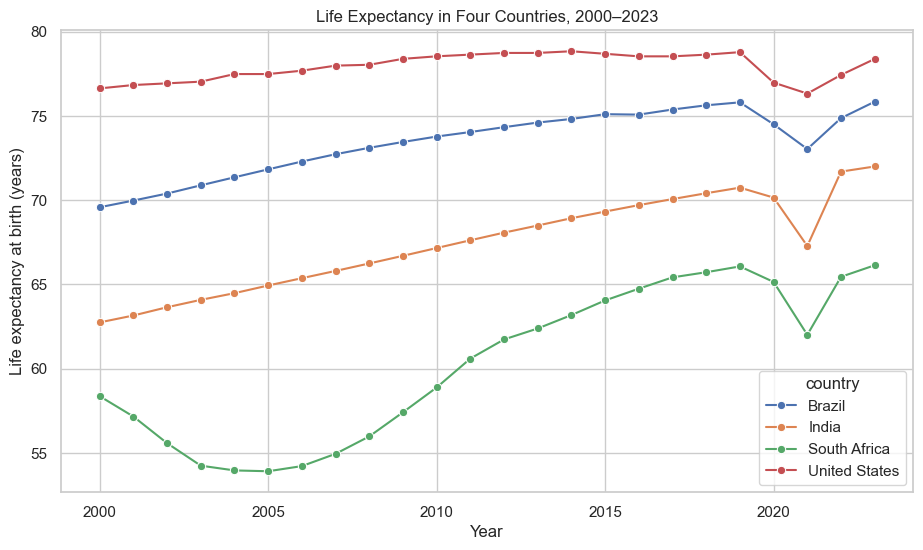

In [25]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=life_expectancy,
    x="year",
    y="life_expectancy",
    hue="country",
    marker="o",
)

plt.title("Life Expectancy in Four Countries, 2000–2023")
plt.xlabel("Year")
plt.ylabel("Life expectancy at birth (years)");

### Guided-example discussion

1. What broad patterns are visible?
2. Which changes deserve further investigation?
3. What is hidden by a national average?
4. Does this graph explain why life expectancy changed?
5. What historical, political, or economic context would be needed?

# Part III — Group API investigation

Work in groups of **2–3**. Select an indicator and three to five countries. Your goal is to develop a small, reproducible data story—not to prove a large causal claim.

## Step 1: Plan the investigation

Complete this section before requesting the data.

- **Group members:**
- **Search term:**
- **Indicator name:**
- **Indicator code:**
- **Indicator units:**
- **What the description says it measures:**
- **Countries and country codes:**
- **Years:**
- **Focused question:**
- **One comparison that might be misleading:**

### Question test

A focused question names the measurement, countries, time period, and comparison.

Too broad:

> What can we learn about education?

More focused:

> How did government education spending as a percentage of GDP change in Brazil, Mexico, and South Africa from 2005 through 2022?

Before continuing, confirm that your selected indicator can actually address your question.

## Step 2: Search for the indicator

In [ ]:
search_term = ""

project_matches = indicator_catalog[
    indicator_catalog["indicator_name"].str.contains(
        search_term, case=False, na=False
    )
    |
    indicator_catalog["description"].str.contains(
        search_term, case=False, na=False
    )
]

project_matches[
    ["indicator_code", "indicator_name", "description"]
].head(20)

## Step 3: Request the data

Replace the empty strings and years. Country codes must be separated by semicolons, such as `"BRA;MEX;ZAF"`.

In [ ]:
project_indicator_code = ""
project_countries = ""
start_year = 2000
end_year = 2023

project_url = (
    "https://api.worldbank.org/v2/"
    f"country/{project_countries}/"
    f"indicator/{project_indicator_code}"
)

project_params = {
    "format": "json",
    "date": f"{start_year}:{end_year}",
    "per_page": 1000,
}

project_response = requests.get(
    project_url,
    params=project_params,
    timeout=30,
)


project_json = project_response.json()

## Step 4: Validate the response

Before constructing the DataFrame:

- display the response metadata;
- display one observation;
- confirm that the requested indicator and countries appear;
- check that `project_json[1]` is not `None`.

In [ ]:
# Validate the response here.

## Step 5: Construct and clean the DataFrame

In [ ]:
project_data = pd.json_normalize(project_json[1])

project_data = project_data[
    ["country.value", "countryiso3code", "date", "value"]
].rename(
    columns={
        "country.value": "country",
        "countryiso3code": "country_code",
        "date": "year",
        "value": "value",
    }
)

project_data["year"] = pd.to_numeric(
    project_data["year"], errors="coerce"
)

project_data["value"] = pd.to_numeric(
    project_data["value"], errors="coerce"
)

project_data = project_data.sort_values(
    ["country", "year"]
)

project_data.head()

## Step 6: Audit the data

Complete all four checks. Then explain whether the countries have comparable coverage.

In [ ]:
# Shape

In [ ]:
# Data types and non-missing counts

In [ ]:
# Missing values

In [ ]:
# Summary by country

**Coverage and missingness notes:**

## Step 7: Use a loop

Complete the loop so it prints one useful statistic for every country. You may calculate the mean, minimum, maximum, number of missing observations, or most recent available value.

In [ ]:
project_country_names = project_data["country"].dropna().unique()

for country in project_country_names:
    country_data = project_data[
        project_data["country"] == country
    ]

    # Calculate and print a useful statistic here.

## Step 8: Filter or group the data

Create at least one additional summary using filtering or `groupby`. It should help answer your focused question.

In [ ]:
# Add your filter or groupby summary here.

**What does the summary reveal?**

## Step 9: Create the visualization

Complete the graph and replace the blank title and y-axis label. The y-axis must include the indicator's units.

In [ ]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=project_data,
    x="year",
    y="value",
    hue="country",
    marker="o",
)

plt.title("")
plt.xlabel("Year")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Visualization check

- Does the title communicate the subject, countries, and period?
- Does the y-axis identify the measurement and units?
- Are missing years visible as gaps?
- Is a line chart appropriate for this indicator?
- Does the graph remain readable with every selected country?
- Have you avoided making a causal claim?

## Step 10: Interpretation

Answer in complete sentences.

1. What does one row in your DataFrame represent?
2. What does your indicator measure?
3. What missing-data or coverage issue did you find?
4. What did the loop or `groupby` summary reveal?
5. What are two observations supported by the graph?
6. What does the graph not establish?
7. What additional historical, political, or economic context would help explain the pattern?
8. What would you investigate next?

**Response:**

>

# Two-minute share-out

Use this structure:

> We used the World Bank API to investigate **[question]**. Our indicator measures **[definition and units]**, and one row represents **[unit of observation]**. Our visualization suggests **[finding]**. A second important pattern is **[finding]**. We would not conclude **[overclaim]** because **[limitation]**. Our next step would be **[context or analysis]**.

#### Exit Ticket

- [link](https://docs.google.com/forms/d/e/1FAIpQLSd9_UfcIlV5NpE2NQWb5RP0RbrG6VZvR-O3EAUuhBMUznwqrQ/viewform?usp=sharing&ouid=106596295392954890759)

# Resources

- [World Bank Indicators API documentation](https://datahelpdesk.worldbank.org/knowledgebase/topics/125589-developer-information)
- [Indicator API queries](https://datahelpdesk.worldbank.org/knowledgebase/articles/898599-indicator-api-queries)
- [API basic call structures](https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structures)
- [World Bank country codes](https://api.worldbank.org/v2/country?format=json&per_page=400)